L. Parker and S. M. Christensen, *MathTensor: A System for Doing Tensor Analysis by Computer* (Addison-Wesley, 1994)

In [1]:
<< mTensor`

# Chapter 7. Electromagnetism and Special Relativity

## 7.1 Maxwell's Electromagnetic Field Equations

### 7.1.1 Units and Maxwell's Equations in *MathTensor*

### 7.1.2 Electromagnetic Wave Equation in Curved Spacetime

In [2]:
Tdefine[F, "-ba"]; Tdefine[A, 1]

In [3]:
expr = CD[lb, F[la, ub]]

CD[lb, F[la, ub]]

In [4]:
vecpotRule = RuleUnique[F[a_, b_], CD[a, A[b]] - CD[b, A[a]]]

F[a_, b_] :> DumFresh[CD[a, A[b]] - CD[b, A[a]]]

In [5]:
expr = expr /. vecpotRule

CD[lb, CD[la, A[ub]]] - CD[lb, CD[ub, A[la]]]

In [6]:
expr[[1]] = CommuteCD[{lb, la}, expr[[1]]]

CD[la, CD[lb, A[ub]]] + A[ub] RicciCD[la, lb]

In [7]:
expr

CD[la, CD[lb, A[ub]]] - CD[lb, CD[ub, A[la]]] + A[ub] RicciCD[la, lb]

In [8]:
lorentzRule = RuleUnique[CD[a_, A[b_]], 0, PairIndexQ[a, b]]

CD[a_, A[b_]] :> DumFresh[0] /; PairIndexQ[a, b]

In [9]:
expr /. lorentzRule

-CD[lb, CD[ub, A[la]]] + A[ub] RicciCD[la, lb]

### 7.1.3 Lorentz Force Density from the Maxwell Stress Tensor

In [10]:
Tdefine[T, "ba"]; Tdefine[J, 1]

F[l$3, l$4] F[u$3, u$4] Metricg[a, b]
T[a_, b_] :> DumFresh[F[a, l$2] F[b, u$2] - -------------------------------------]
                                                              4
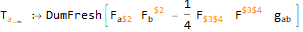

In [11]:
maxwellTtoFrule = 
 RuleUnique[T[a_, b_], 
  F[a, lc] F[b, uc] - 1/4 Metricg[a, b] F[lc, ld] F[uc, ud]]

In [12]:
maxwellCyclicRule = 
 RuleUnique[CD[a_, F[b_, c_]], -CD[b, F[c, a]] - CD[c, F[a, b]]]

CD[a_, F[b_, c_]] :> DumFresh[-CD[b, F[c, a]] - CD[c, F[a, b]]]

In [31]:
maxwellDivergencdRule = 
 RuleUnique[CD[b_, F[a_, c_]], -J[c], PairIndexQ[b, a]]

CD[b_, F[a_, c_]] :> DumFresh[-J[c]] /; PairIndexQ[b, a]

In [32]:
CD[lb, T[ua, ub]]

CD[lb, T[ua, ub]]

CD[lb, F[ub, uc]] F[ua, lc] + CD[lb, F[ua, lc]] F[ub, uc] - 
 
    CD[lb, F[uc, ud]] F[lc, ld] Metricg[ua, ub]
>   ------------------------------------------- - 
                         4
 
    CD[lb, F[lc, ld]] F[uc, ud] Metricg[ua, ub]
>   -------------------------------------------
                         4
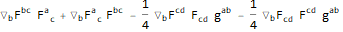

In [33]:
% /. maxwellTtoFrule

-(CD[ua, F[ub, uc]] F[lb, lc])
------------------------------ - CD[ub, F[ua, uc]] F[lc, lb] + 
              2
 
>   CD[lb, F[ub, uc]] F[ua, lc]
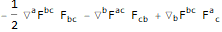

In [34]:
% // Tsimplify

-(CD[ua, F[ub, uc]] F[lb, lc])
------------------------------ - CD[ub, F[ua, uc]] F[lc, lb] + 
              2
 
>   CD[lb, F[ub, uc]] F[ua, lc]
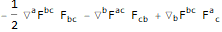

In [35]:
expr = %

CD[ub, F[uc, ua]] F[lb, lc]   CD[uc, F[ua, ub]] F[lb, lc]
--------------------------- + ---------------------------
             2                             2
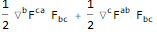

In [36]:
expr[[1]] /. maxwellCyclicRule

In [37]:
expr[[1]] = % // Tsimplify

CD[ub, F[ua, uc]] F[lc, lb]

In [38]:
expr

CD[lb, F[ub, uc]] F[ua, lc]

In [39]:
% /. maxwellDivergencdRule

-(F[ua, lc] J[uc])

## 7.2 Special Relativistic Collisions

### 7.2.1 Elastic Collision of Two Particles of Equal Mass

### 7.2.2 Solution in Center-of-Momentum Frame

### 7.2.3 Transformation to Laboratory Frame

In [40]:
SetDimension[4]

In [41]:
coSys = {x, y, z, t};
trans = {\[Gamma][uSp] (x + uSp t), y, z,
          \[Gamma][uSp] (t + uSp x/c^2)};

In [43]:
lorentz[a_, b_] := Ttransform[a, b, coSys, trans]

In [44]:
Tdefine[{pi, ppi}, 1]

In [45]:
lorentz[ppi[ua], pi]

In [46]:
pi[1]

ppi[1] γ[uSp] + uSp ppi[4] γ[uSp]

uSp ppi[1] γ[uSp]
----------------- + ppi[4] γ[uSp]
        2
       c
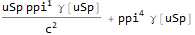

In [47]:
pi[4]

In [48]:
SetComponents[ppi[ua], {\[Gamma][uSp] m uSp, 0, 0, \[Gamma][uSp] m}]

In [49]:
pi[1]

2
2 m uSp γ[uSp]

In [50]:
eqpi1 = \[Gamma][uiS] m uiS == pi[1]

2
m uiS γ[uiS] == 2 m uSp γ[uSp]

2      2        2
            m (c  + uSp ) γ[uSp]
m γ[uiS] == ---------------------
                      2
                     c
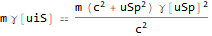

In [51]:
eqpi4 = \[Gamma][uiS] m == pi[4] // Simplify

2
       2 c  uSp
uiS == ---------
        2      2
       c  + uSp
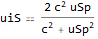

In [52]:
eqpi1[[1]]/eqpi4[[1]] == eqpi1[[2]]/eqpi4[[2]]

2         4    2    2             2         4    2    2
         c  - Sqrt[c  - c  uiS ]           c  + Sqrt[c  - c  uiS ]
{{uSp -> -----------------------}, {uSp -> -----------------------}}
                   uiS                               uiS
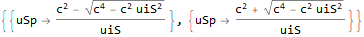

In [53]:
Solve[%, uSp]

2         4    2    2
       c  + Sqrt[c  - c  uiS ]
uSp -> -----------------------
                 uiS
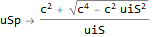

In [54]:
uSpRule = %[[2, 1]] // Simplify

In [55]:
Tdefine[{pf, ppf}, 1]

In [63]:
SetComponents[ppf[ua],
               {\[Gamma][uSp] m uSp Cos[thetaSp],
                \[Gamma][uSp] m uSp Sin[thetaSp],
                0,
                \[Gamma][uSp] m}]

In [64]:
lorentz[ppf[ua], pf]

In [65]:
pf[1]

2
m uSp (1 + Cos[thetaSp]) γ[uSp]

In [67]:
eqpf1 = \[Gamma][ufS] m ufS Cos[thetaS] == pf[1]

2
m ufS Cos[thetaS] γ[ufS] == m uSp (1 + Cos[thetaSp]) γ[uSp]

In [68]:
eqpf2 = \[Gamma][ufS] m ufS Sin[thetaS] == pf[2]

m ufS Sin[thetaS] γ[ufS] == m uSp Sin[thetaSp] γ[uSp]

2      2                     2
            m (c  + uSp  Cos[thetaSp]) γ[uSp]
m γ[ufS] == ----------------------------------
                             2
                            c
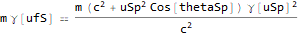

In [69]:
eqpf4 = \[Gamma][ufS] m == pf[4]

thetaSp
               Tan[-------]
                      2
Tan[thetaS] == ------------
                  γ[uSp]
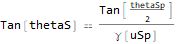

In [70]:
eqthetaS = 
 eqpf2[[1]]/eqpf1[[1]] == eqpf2[[2]]/eqpf1[[2]] // Simplify

In [71]:
Solve[eqthetaS, thetaSp]

{{thetaSp -> ConditionalExpression[2 (ArcTan[Tan[thetaS] γ[uSp]] + Pi C[1]), 
 
>      C[1] ∈ Integers]}}

In [72]:
thetaSpRule = %[[1, 1]]

thetaSp -> ConditionalExpression[2 (ArcTan[Tan[thetaS] γ[uSp]] + Pi C[1]), 
 
>    C[1] ∈ Integers]

2      2                     2
          (c  + uSp  Cos[thetaSp]) γ[uSp]
γ[ufS] == --------------------------------
                          2
                         c
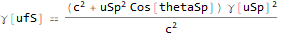

In [73]:
eqpf4[[1]]/m == eqpf4[[2]]/m

In [74]:
Tdefine[{qf, qpf}, 1]

In [75]:
SetComponents[qpf[ua],
               {-\[Gamma][uSp] m uSp Cos[thetaSp],
                -\[Gamma][uSp] m uSp Sin[thetaSp],
                0,
                \[Gamma][uSp] m}]

In [76]:
lorentz[qpf[ua], qf]

In [77]:
eqqf1 = \[Gamma][wf] m wf Cos[phi] == qf[1]

2
m wf Cos[phi] γ[wf] == -(m uSp (-1 + Cos[thetaSp]) γ[uSp] )

In [78]:
eqqf2 = -\[Gamma][wf] m wf Sin[phi] == qf[2]

-(m wf Sin[phi] γ[wf]) == -(m uSp Sin[thetaSp] γ[uSp])

2      2                     2
           m (c  - uSp  Cos[thetaSp]) γ[uSp]
m γ[wf] == ----------------------------------
                            2
                           c
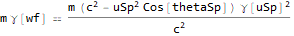

In [79]:
eqqf4 = \[Gamma][wf] m == qf[4]

2      2                     2
            m (c  + uSp  Cos[thetaSp]) γ[uSp]
m γ[ufS] == ----------------------------------
                             2
                            c
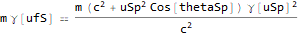

In [80]:
eqpf4

Sin[thetaSp]
-Tan[phi] == --------------------------
             (-1 + Cos[thetaSp]) γ[uSp]
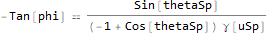

In [81]:
eqphi = eqqf2[[1]]/eqqf1[[1]] == eqqf2[[2]]/eqqf1[[2]]

Sin[thetaSp]
Tan[phi] == -(--------------------------)
              (-1 + Cos[thetaSp]) γ[uSp]
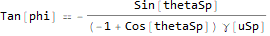

In [82]:
eqphi = -%[[1]] == -%[[2]]

ConditionalExpression[2 Tan[phi] == 
 
                                2         4    2    2
                               c  + Sqrt[c  - c  uiS ]             2
>    (Csc[ArcTan[Tan[thetaS] γ[-----------------------]] + Pi C[1]]  
                                         uiS
 
                                    2         4    2    2
                                   c  + Sqrt[c  - c  uiS ]
>       Sin[2 ArcTan[Tan[thetaS] γ[-----------------------]]]) / 
                                             uiS
 
         2         4    2    2
        c  + Sqrt[c  - c  uiS ]
>     γ[-----------------------], C[1] ∈ Integers]
                  uiS
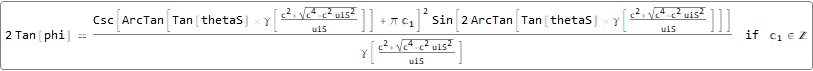

In [83]:
eqphi //. {thetaSpRule, uSpRule} // Simplify

나머지 생략...